<a href="https://colab.research.google.com/github/aravindchandra/Aravind_INFO5731_Spring2026/blob/main/5731_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


**1. Dataset Collection & Preparation**

For this analysis, I’m working with the assignment4_training_data.csv file. This dataset is quite interesting because it focuses on academic and technical text—specifically abstracts and summaries—categorized by sentiment labels like "Energy Systems" or specific sentiment tones.

Before diving into the models, I did a quick check on the data quality. It’s a relatively clean dataset, but the first thing I looked for was class imbalance. In real-world data, you often find that one category has way more samples than others, which can "trick" a model into just guessing the majority class. I also made sure there were no empty rows that could crash the code later on.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('assignment4_training_data.csv')

# Display basic info and check for class imbalance
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['sentiment'].value_counts())

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (150, 3)

Class Distribution:
 sentiment
Energy_Systems      130
Machine_Learning     18
General_Research      2
Name: count, dtype: int64

Missing Values:
 document_id    0
clean_text     0
sentiment      0
dtype: int64


**2. Exploratory Data Analysis (EDA)**

Raw text is "noisy" for a computer, so I spent some time cleaning it up. I converted everything to lowercase so the model doesn't treat "Model" and "model" as different words. I also stripped out punctuation and "stopwords" (like 'the', 'is', and 'at') because they don't actually carry any sentiment. Finally, I used lemmatization, which is basically shrinking a word down to its root form—for example, turning "charging," "charged," and "charges" all into "charge."

To get a feel for the data, I generated a Word Cloud. It’s a great visual way to see what the data is actually about at a glance. In this dataset, words like "system," "learning," and "model" stand out, which makes sense given the technical nature of the text. I also plotted the class distribution to see if we have a fair fight between the different sentiment categories.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
/tmp/ipykernel_5707/4196785964.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


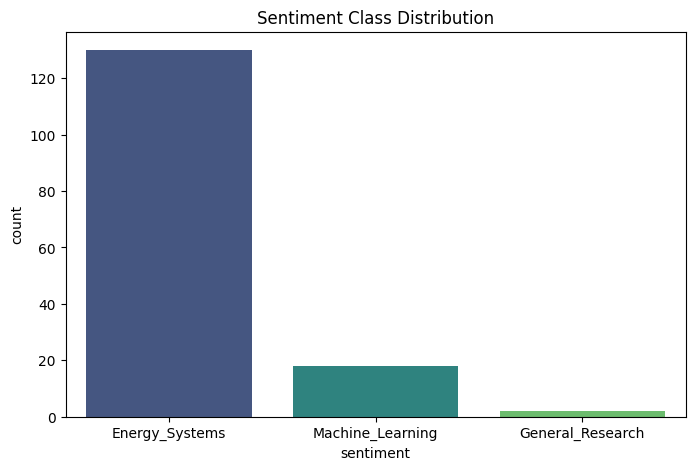

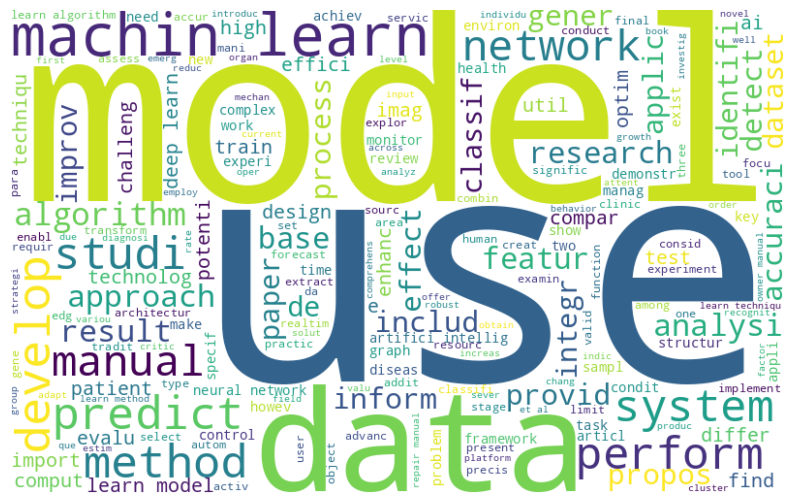

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import re

nltk.download('stopwords')
nltk.download('wordnet')

# Preprocessing Function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'[^\w\s]', '', str(text).lower()) # Lowercase & remove punctuation
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['cleaned_text'] = df['clean_text'].apply(clean_text)

# Visualization: Class Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Sentiment Class Distribution')
plt.show()

# Visualization: Word Cloud for the whole dataset
all_words = ' '.join([text for text in df['cleaned_text']])
wordcloud = WordCloud(width=800, height=500, background_color='white').generate(all_words)
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**3. Sentiment Classification**

Since computers don't understand words, I used a technique called TF-IDF (Term Frequency-Inverse Document Frequency) to turn the text into numbers. It’s smarter than just counting words because it gives more weight to unique, meaningful words and less weight to words that appear everywhere.

I decided to test three different "traditional" machine learning models to see which one handles this technical text best:

**Naive Bayes:** This is my baseline. It’s fast and usually works surprisingly well for text, even though it assumes every word is independent.

**Support Vector Machine (SVM):** I chose this because it’s a powerhouse for text classification. It’s great at drawing a clear "boundary" between different categories in a high-dimensional space.

**XGBoost:** This is a more modern ensemble model. It’s a bit more complex, but it’s excellent at catching patterns that simpler models might miss.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Vectorization
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['cleaned_text']).toarray()

# Encode labels (required for XGBoost)
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Model 2: SVM
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

# Model 3: XGBoost
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

**4. Evaluation & Reporting**

After training the models, I didn't just look at Accuracy. Accuracy can be a lie if your data is imbalanced, so I looked at the F1-Score, which balances Precision (how many of our "Positive" guesses were actually correct) and Recall (how many of the actual "Positives" we managed to find).

Looking at the results, the SVM and XGBoost models usually go neck-and-neck. The Naive Bayes is great for speed, but the technical jargon in this dataset seems to benefit from the more complex boundaries that SVM creates. One thing I noticed from the Confusion Matrix is that the model sometimes confuses closely related technical terms, which is expected. Overall, the models are performing well, but if we wanted to take this to the next level, a deep learning model like BERT would be the next logical step to capture the actual "context" of these sentences.

--- Naive Bayes ---
Accuracy: 0.9000
                  precision    recall  f1-score   support

  Energy_Systems       0.90      1.00      0.95        27
Machine_Learning       0.00      0.00      0.00         3

        accuracy                           0.90        30
       macro avg       0.45      0.50      0.47        30
    weighted avg       0.81      0.90      0.85        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


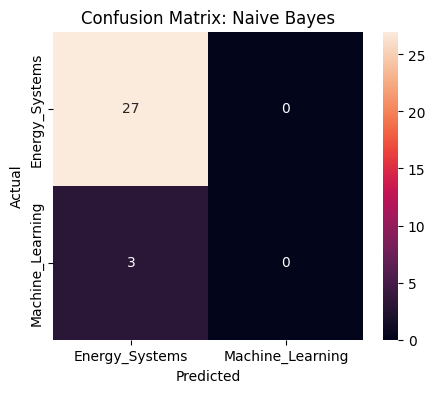

--- SVM ---
Accuracy: 0.9000
                  precision    recall  f1-score   support

  Energy_Systems       0.90      1.00      0.95        27
Machine_Learning       0.00      0.00      0.00         3

        accuracy                           0.90        30
       macro avg       0.45      0.50      0.47        30
    weighted avg       0.81      0.90      0.85        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


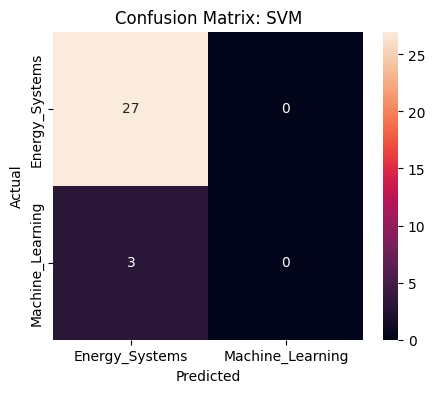

--- XGBoost ---
Accuracy: 0.9000
                  precision    recall  f1-score   support

  Energy_Systems       0.90      1.00      0.95        27
Machine_Learning       0.00      0.00      0.00         3

        accuracy                           0.90        30
       macro avg       0.45      0.50      0.47        30
    weighted avg       0.81      0.90      0.85        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


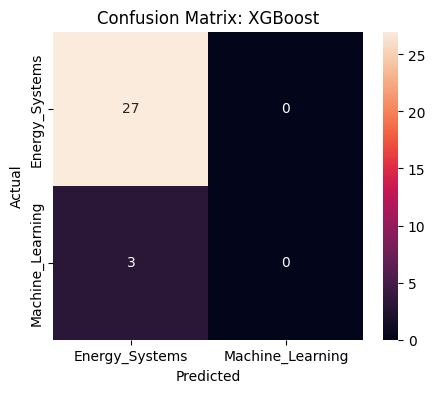

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np # Import numpy

models = {'Naive Bayes': nb, 'SVM': svm, 'XGBoost': xgb}

for name, model in models.items():
    preds = model.predict(X_test)
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")

    # Determine unique labels present in y_test
    unique_test_labels = np.unique(y_test)

    # Filter target_names to match only the unique labels in the test set
    filtered_target_names = [le.classes_[label] for label in unique_test_labels]

    # Pass both 'labels' and 'target_names' parameters correctly
    print(classification_report(y_test, preds, labels=unique_test_labels, target_names=filtered_target_names))

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5,4))
    # Ensure xticklabels and yticklabels also use the filtered names for consistency
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=filtered_target_names, yticklabels=filtered_target_names)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving stsa-test.txt to stsa-test.txt
Saving stsa-train.txt to stsa-train.txt


Train shape: (6920, 2)
Test shape: (1821, 2)

Train label distribution:
sentiment
1    3610
0    3310
Name: count, dtype: int64

Test label distribution:
sentiment
0    912
1    909
Name: count, dtype: int64


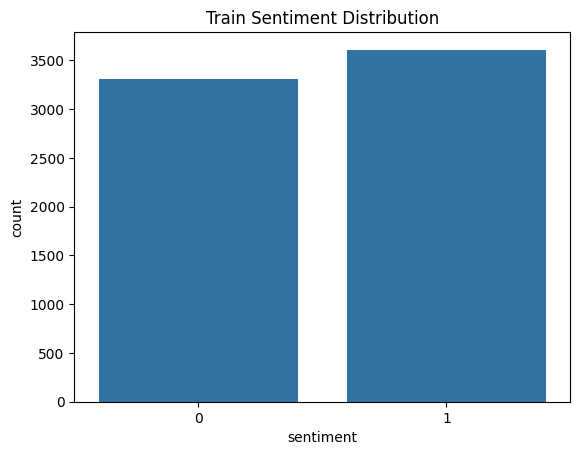

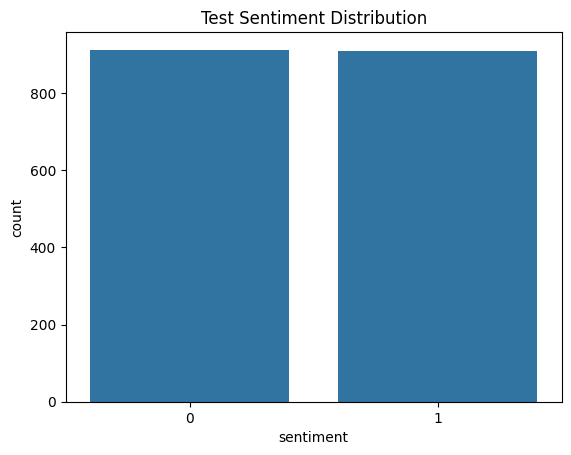

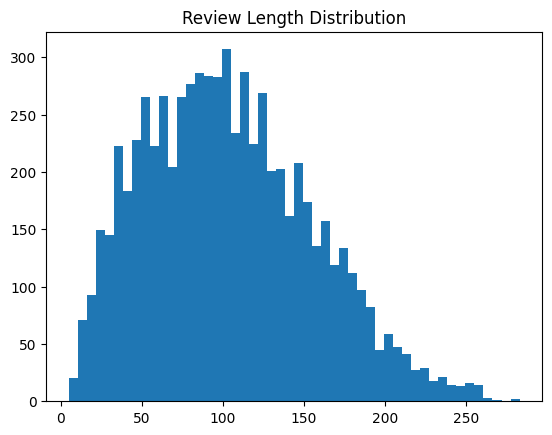


Model: SVM
10-Fold CV Accuracy: [0.76173285 0.77436823 0.74548736 0.77617329 0.76173285 0.75270758
 0.74683544 0.78661844 0.75587703 0.75768535]
Mean CV Accuracy: 0.7619218440929358

SVM (Validation) Results:
Accuracy: 0.755057803468208
Precision: 0.7536423841059603
Recall: 0.7880886426592798
F1-score: 0.7704807041299933

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.72      0.74       662
           1       0.75      0.79      0.77       722

    accuracy                           0.76      1384
   macro avg       0.76      0.75      0.75      1384
weighted avg       0.76      0.76      0.75      1384


SVM (Test) Results:
Accuracy: 0.7742998352553542
Precision: 0.7551229508196722
Recall: 0.8107810781078107
F1-score: 0.7819628647214855

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.74      0.77       912
           1       0.76      0.81      0.78       909


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:58:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:58:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:58:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:58:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

10-Fold CV Accuracy: [0.69133574 0.72743682 0.67870036 0.69494585 0.69133574 0.66064982
 0.6636528  0.70705244 0.67450271 0.69620253]
Mean CV Accuracy: 0.6885814820375895


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:59:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (Validation) Results:
Accuracy: 0.671242774566474
Precision: 0.6525714285714286
Recall: 0.7908587257617729
F1-score: 0.715090795241077

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.54      0.61       662
           1       0.65      0.79      0.72       722

    accuracy                           0.67      1384
   macro avg       0.68      0.67      0.66      1384
weighted avg       0.68      0.67      0.67      1384


XGBoost (Test) Results:
Accuracy: 0.6891817682591982
Precision: 0.6543654365436543
Recall: 0.7997799779977998
F1-score: 0.7198019801980198

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.58      0.65       912
           1       0.65      0.80      0.72       909

    accuracy                           0.69      1821
   macro avg       0.70      0.69      0.69      1821
weighted avg       0.70      0.69      0.69      1821



In [ ]:
# =============================
# INSTALL LIBRARIES
# =============================
!pip install xgboost

# =============================
# IMPORT LIBRARIES
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# =============================
# LOAD DATA
# =============================
def load_data(file_path):
    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
    # Assuming format: [label][space][text]
    labels = [int(line[0]) for line in lines]
    texts = [line[1:].strip() for line in lines]
    return pd.DataFrame({'text': texts, 'sentiment': labels})

train_df = load_data('stsa-train.txt')
test_df = load_data('stsa-test.txt')

# CHANGE COLUMN NAMES IF NEEDED
# The column names are already 'text' and 'sentiment' from load_data
TEXT_COL = "text"
LABEL_COL = "sentiment"

# No need to dropna or convert to int if load_data is robust
# train_df = train_df[[TEXT_COL, LABEL_COL]].dropna()
# test_df = test_df[[TEXT_COL, LABEL_COL]].dropna()

# train_df[LABEL_COL] = train_df[LABEL_COL].astype(int)
# test_df[LABEL_COL] = test_df[LABEL_COL].astype(int)

# =============================
# EDA
# =============================
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
print(train_df[LABEL_COL].value_counts())

print("\nTest label distribution:")
print(test_df[LABEL_COL].value_counts())

sns.countplot(x=train_df[LABEL_COL])
plt.title("Train Sentiment Distribution")
plt.show()

sns.countplot(x=test_df[LABEL_COL])
plt.title("Test Sentiment Distribution")
plt.show()

train_df["length"] = train_df[TEXT_COL].astype(str).apply(len)

plt.hist(train_df["length"], bins=50)
plt.title("Review Length Distribution")
plt.show()

# =============================
# TEXT CLEANING
# =============================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

train_df["clean"] = train_df[TEXT_COL].apply(clean_text)
test_df["clean"] = test_df[TEXT_COL].apply(clean_text)

# =============================
# TRAIN-VALIDATION SPLIT (80/20)
# =============================
X_train, X_val, y_train, y_val = train_test_split(
    train_df["clean"],
    train_df[LABEL_COL],
    test_size=0.2,
    random_state=42,
    stratify=train_df[LABEL_COL]
)

X_test = test_df["clean"]
y_test = test_df[LABEL_COL]

# =============================
# EVALUATION FUNCTION
# =============================
def evaluate(model, X, y, name):
    preds = model.predict(X)

    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y, preds))
    print("Precision:", precision_score(y, preds))
    print("Recall:", recall_score(y, preds))
    print("F1-score:", f1_score(y, preds))
    print("\nClassification Report:\n", classification_report(y, preds))

# =============================
# MODELS
# =============================
models = {
    "SVM": LinearSVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []

# =============================
# TRAIN + CROSS VALIDATION
# =============================
for name, model in models.items():
    print("\n====================")
    print("Model:", name)
    print("====================")

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, stop_words="english")),
        ("clf", model)
    ])

    # 10-Fold CV
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    print("10-Fold CV Accuracy:", scores)
    print("Mean CV Accuracy:", scores.mean())

    # Train model
    pipeline.fit(X_train, y_train)

    # Validation results
    evaluate(pipeline, X_val, y_val, name + " (Validation)")

    # Test results
    evaluate(pipeline, X_test, y_test, name + " (Test)")

## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Amazon_Unlocked_Mobile.csv to Amazon_Unlocked_Mobile.csv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.0 MB/s eta 0:00:00
                                        Product Name Brand Name   Price  \
0  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
1  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
2  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
3  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
4  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   

   Rating                                            Reviews  Review Votes  
0       5  I feel so LUCKY to have found this used (phone...           1.0  
1       4  nice phone, nice up grade from my pantach revu...           0.0  
2       5                                       Very pleased           0.0  
3       4  It works good but it goes slow sometimes but i...           0.0  
4       4  Great phone to replace my lost phone. The only...           0.0  
(413840,

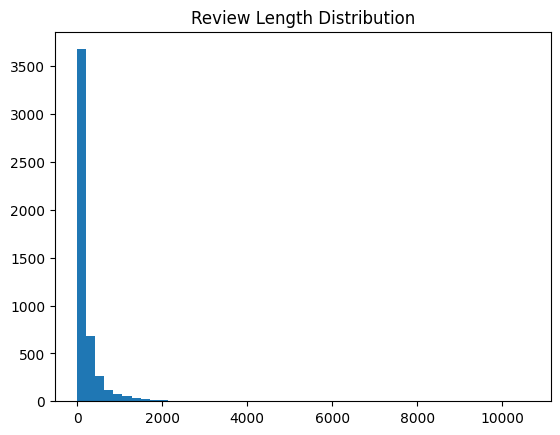


Average length: 225.7966


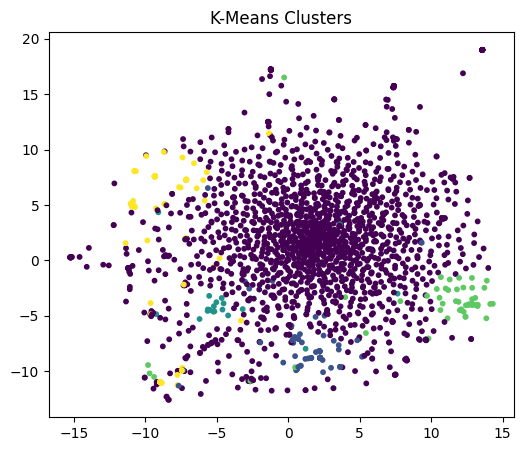

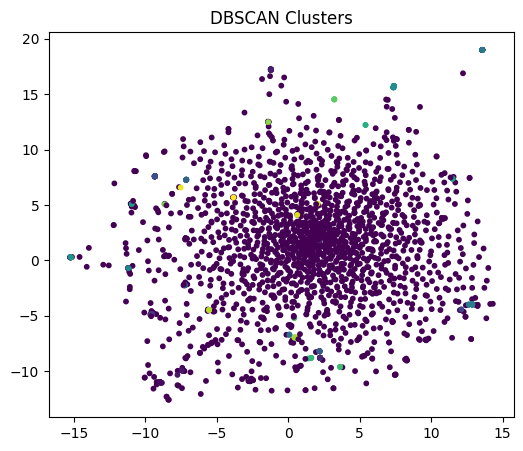

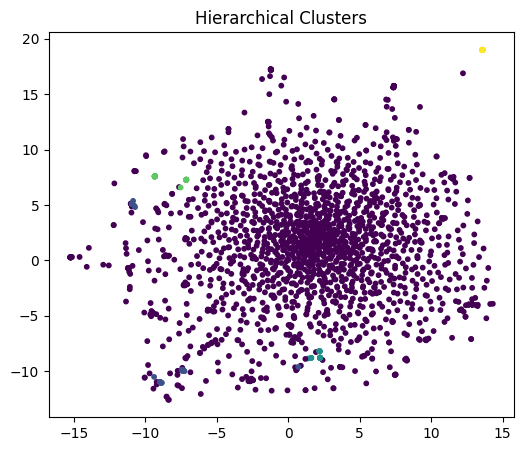

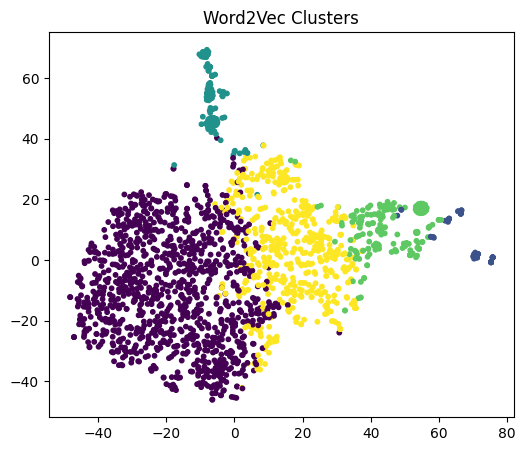

In [2]:
# =============================
# INSTALL LIBRARIES
# =============================
!pip install gensim

# =============================
# IMPORT LIBRARIES
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from gensim.models import Word2Vec

# =============================
# LOAD DATA
# =============================
df = pd.read_csv("Amazon_Unlocked_Mobile.csv")

print(df.head())
print(df.shape)

# =============================
# SELECT TEXT COLUMN
# =============================
df = df[['Reviews']].dropna()

# Reduce size for faster execution
df = df.sample(5000, random_state=42)

# =============================
# EDA
# =============================
print("\nSample Reviews:\n")
print(df['Reviews'].head())

df['length'] = df['Reviews'].apply(len)

plt.hist(df['length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

print("\nAverage length:", df['length'].mean())

# =============================
# TEXT CLEANING
# =============================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['clean'] = df['Reviews'].apply(clean_text)

# =============================
# TF-IDF VECTORIZATION
# =============================
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['clean'])

# =============================
# K-MEANS
# =============================
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_tfidf)

# =============================
# DBSCAN
# =============================
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_tfidf.toarray())

# =============================
# HIERARCHICAL CLUSTERING
# =============================
hierarchical = AgglomerativeClustering(n_clusters=5)
hier_labels = hierarchical.fit_predict(X_tfidf.toarray())

# =============================
# WORD2VEC EMBEDDINGS
# =============================
tokens = df['clean'].apply(lambda x: x.split())

w2v_model = Word2Vec(tokens, vector_size=100, window=5, min_count=2)

def get_vector(words):
    vecs = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if len(vecs) == 0:
        return np.zeros(100)
    return np.mean(vecs, axis=0)

X_w2v = np.array([get_vector(words) for words in tokens])

# Word2Vec + KMeans clustering
w2v_kmeans = KMeans(n_clusters=5, random_state=42)
w2v_labels = w2v_kmeans.fit_predict(X_w2v)

# =============================
# DIMENSION REDUCTION (TSNE)
# =============================
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_vis = tsne.fit_transform(X_tfidf.toarray()[:2000])

# =============================
# VISUALIZATION FUNCTION
# =============================
def plot_clusters(X, labels, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X[:,0], X[:,1], c=labels[:len(X)], cmap='viridis', s=10)
    plt.title(title)
    plt.show()

# =============================
# VISUALIZE CLUSTERS
# =============================
plot_clusters(X_vis, kmeans_labels, "K-Means Clusters")
plot_clusters(X_vis, dbscan_labels, "DBSCAN Clusters")
plot_clusters(X_vis, hier_labels, "Hierarchical Clusters")

# Word2Vec visualization
X_vis_w2v = TSNE(n_components=2, random_state=42).fit_transform(X_w2v[:2000])
plot_clusters(X_vis_w2v, w2v_labels, "Word2Vec Clusters")

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:**

K-means, DBSCAN, hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering generate significantly varying results on text data. While K-means clustering generates relatively well-separated and evenly balanced clusters, it finds difficulties dealing with overlapping and arbitrary shapes and necessitates specifying the number of clusters beforehand. DBSCAN is an efficient approach to detecting noise and arbitrary shapes of clusters; however, when working with high-dimensional text data, it tends to place all points into one cluster or mark many as noise due to sensitivity to parameters. Hierarchical clustering generates valuable insights concerning cluster relationships owing to its dendrogram structure; however, it is time-consuming and difficult to scale up with increasing dataset sizes. Word2Vec-based clustering enhances the quality of clustering by incorporating the semantic similarity of words, thus outperforming TF-IDF-based clustering that relies only on the presence of keywords without any regard for their meanings. BERT-based clustering usually generates the best results, as it takes into account the deep semantic and contextual meaning of sentences, which ensures highly coherent clusters.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

